# Student Success Factors Dashboard

## Personalized Student Intelligence & Recommendation System

### Objective

This notebook focuses on personalized student analytics, cohort comparison, behavioral insights, recommendation generation, and student success intelligence using survey-based academic data.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

df = pd.read_csv("../data/processed/clean_survey_responses.csv")

df.head()

,submission_timestamp,anonymous_id,department,year_of_study,current_semester,highest_scoring_course_code,highest_grade,lowest_scoring_course_code,lowest_grade,attendance_percent,study_hours_week,attends_tutorial,assignment_completion_rate,gpa,course_difficulty,main_challenge,study_group,online_resources,success_factor,preferred_study_time,failed_course_before,laptop_access,internet_quality,lives_in_dorm,part_time_job,sleep_hours_night,mental_health_rating,academic_risk,engagement_score
0,2025-11-03 08:14:22,panda12,Software Engineering,Year 3,2025/2026 First Semester,CSEg3203,A-,Math2201,C,88.0,12,Yes,95,3.21,3,Time management,Yes,Yes regularly,Study groups and past exams help me most,Evening,No,Yes,Good,Yes,No,7,4,Low Risk,97.2
1,2025-11-03 08:33:11,ninja07,Software Engineering,Year 3,2025/2026 First Semester,SEng3201,B+,Math2201,C-,74.0,8,No,79,2.71,4,Programming difficulty,No,Sometimes,Watching YouTube tutorials when stuck,Night,Yes,Yes,Fair,No,No,6,3,Moderate Risk,77.2
2,2025-11-03 08:55:40,bytecoder,Software Engineering,Year 3,2025/2026 First Semester,CSEg3203,A,CSEg3204,B-,93.0,16,Yes,98,3.82,2,None really,Yes,Yes regularly,Consistent revision and coding practice,Morning,No,Yes,Good,No,No,8,5,Low Risk,108.4
3,2025-11-03 09:10:18,starlite,Software Engineering,Year 3,2025/2026 First Semester,SEng3201,B,Math2201,D+,62.0,5,No,68,2.14,5,Lack of resources,No,Never,Trying to survive exams only,Afternoon,Yes,No,Poor,Yes,Yes,5,2,High Risk,62.0
4,2025-11-03 09:31:56,codewave,Software Engineering,Year 3,2025/2026 First Semester,CSEg3203,A,Math2201,B,96.0,20,Yes,100,3.94,2,NaN,Yes,Yes regularly,Discipline and active practice,Morning,No,Yes,Good,No,No,7,5,Low Risk,118.4


# 1. Academic Risk Segmentation


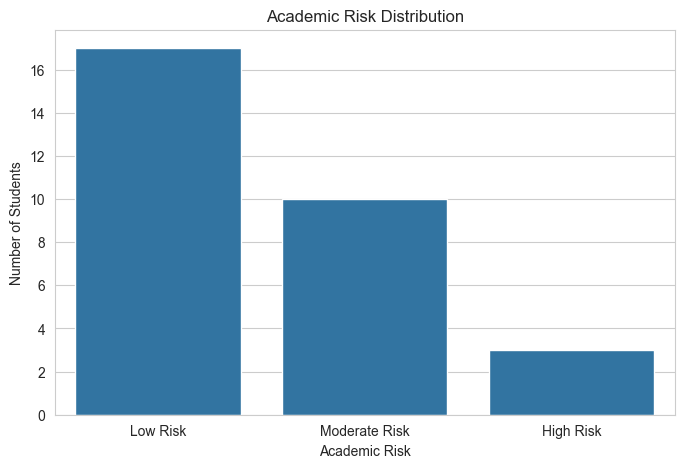

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="academic_risk",
    order=df["academic_risk"].value_counts().index
)

plt.title("Academic Risk Distribution")
plt.xlabel("Academic Risk")
plt.ylabel("Number of Students")

plt.show()

## Interpretation

Most students fall within the low-to-moderate risk categories, indicating generally stable academic performance across the cohort.

## Recommendation

Provide early intervention programs for high-risk students before performance declines further.


# 2. Engagement Score vs GPA


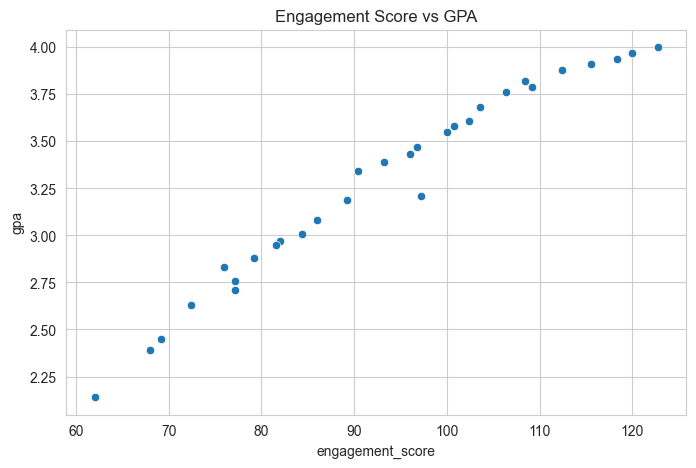

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="engagement_score",
    y="gpa"
)

plt.title("Engagement Score vs GPA")

plt.show()

## Interpretation

Students with higher engagement scores tend to achieve higher GPAs, suggesting a positive relationship between participation and academic success.

## Recommendation

Increase student engagement through interactive learning activities and participation incentives.


# 3. Tutorial Attendance Impact


In [5]:
tutorial_gpa = (
    df.groupby("attends_tutorial")["gpa"]
    .mean()
    .reset_index()
)

tutorial_gpa

,attends_tutorial,gpa
0,No,2.6710
1,Yes,3.5805


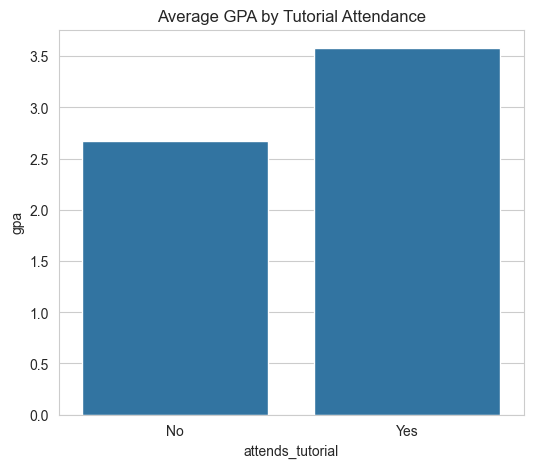

In [ ]:
plt.figure(figsize=(6, 5))

sns.barplot(
    data=tutorial_gpa,
    x="attends_tutorial",
    y="gpa"
)

plt.title("Average GPA by Tutorial Attendance")

plt.show()

## Interpretation

Students who attend tutorials achieve substantially higher average GPAs (3.58) than those who do not (2.67).

## Recommendation

Encourage tutorial participation through awareness campaigns and structured academic support programs.


# 4. Study Group Participation Analysis


In [7]:
study_group_gpa = (
    df.groupby("study_group")["gpa"]
    .mean()
    .reset_index()
)

study_group_gpa

,study_group,gpa
0,No,2.6710
1,Yes,3.5805


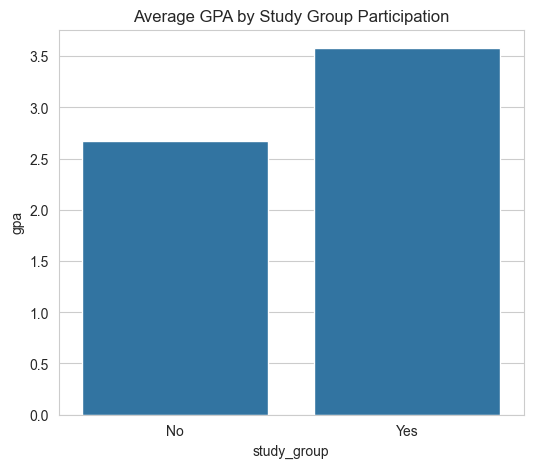

In [ ]:
plt.figure(figsize=(6, 5))

sns.barplot(
    data=study_group_gpa,
    x="study_group",
    y="gpa"
)

plt.title("Average GPA by Study Group Participation")

plt.show()

## Interpretation

Students participating in study groups demonstrate significantly higher academic performance than non-participants.

## Recommendation

Promote peer-learning initiatives and organized study groups across departments.


# 5. Sleep Hours vs GPA


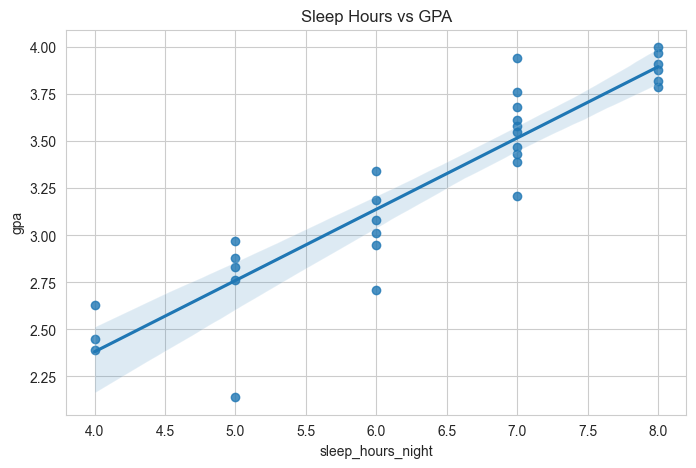

In [ ]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="sleep_hours_night",
    y="gpa"
)

plt.title("Sleep Hours vs GPA")

plt.show()

## Interpretation

The trendline suggests that adequate sleep is associated with improved academic performance.

## Recommendation

Educate students about healthy sleep habits as part of academic success initiatives.


# 6. Internet Quality vs GPA


In [10]:
internet_gpa = (
    df.groupby("internet_quality")["gpa"]
    .mean()
    .reset_index()
)

internet_gpa

,internet_quality,gpa
0,Fair,2.972000
1,Good,3.686875
2,Poor,2.402500


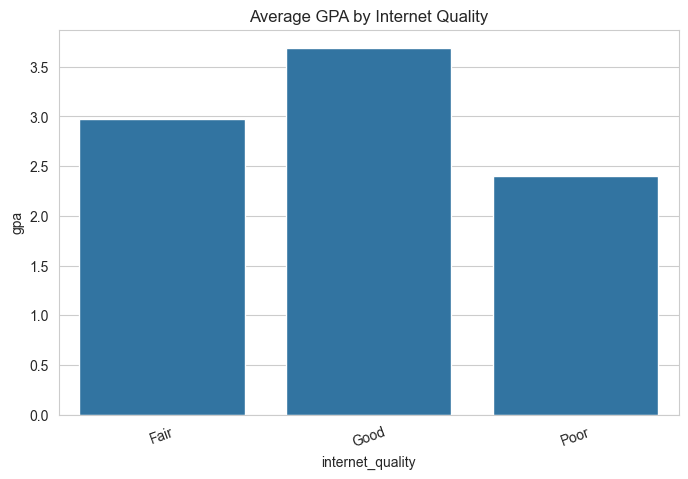

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=internet_gpa,
    x="internet_quality",
    y="gpa"
)

plt.title("Average GPA by Internet Quality")

plt.xticks(rotation=20)

plt.show()

## Interpretation

Students with good internet access achieve the highest average GPA, while poor connectivity is associated with lower academic performance.

## Recommendation

Universities should improve digital infrastructure and provide internet support for students facing connectivity challenges.


# 7. Student Lifestyle Analysis


In [12]:
lifestyle_analysis = df.groupby("part_time_job")[
    ["gpa", "mental_health_rating"]
].mean()

lifestyle_analysis

,gpa,mental_health_rating
part_time_job,,
No,3.512273,4.090909
Yes,2.631250,2.500000


In [13]:
dorm_analysis = df.groupby("lives_in_dorm")[
    ["gpa", "mental_health_rating"]
].mean()

dorm_analysis

,gpa,mental_health_rating
lives_in_dorm,,
No,3.655625,4.375000
Yes,2.845000,2.857143


## Interpretation

Students without part-time jobs and those living outside dormitories report both higher GPAs and better mental health ratings.

## Recommendation

Provide flexible support services for working students and improve student well-being resources within dormitories.


# 8. Personal Student Lookup Simulation


In [14]:
student_id = "panda12"

student = df[df["anonymous_id"] == student_id]

student

,submission_timestamp,anonymous_id,department,year_of_study,current_semester,highest_scoring_course_code,highest_grade,lowest_scoring_course_code,lowest_grade,attendance_percent,study_hours_week,attends_tutorial,assignment_completion_rate,gpa,course_difficulty,main_challenge,study_group,online_resources,success_factor,preferred_study_time,failed_course_before,laptop_access,internet_quality,lives_in_dorm,part_time_job,sleep_hours_night,mental_health_rating,academic_risk,engagement_score
0,2025-11-03 08:14:22,panda12,Software Engineering,Year 3,2025/2026 First Semester,CSEg3203,A-,Math2201,C,88.0,12,Yes,95,3.21,3,Time management,Yes,Yes regularly,Study groups and past exams help me most,Evening,No,Yes,Good,Yes,No,7,4,Low Risk,97.2


In [15]:
cohort_comparison = pd.DataFrame({
    "Metric": [
        "GPA",
        "Attendance",
        "Study Hours",
        "Assignment Completion",
        "Sleep Hours",
        "Mental Health"
    ],
    "Student Value": [
        student["gpa"].mean(),
        student["attendance_percent"].mean(),
        student["study_hours_week"].mean(),
        student["assignment_completion_rate"].mean(),
        student["sleep_hours_night"].mean(),
        student["mental_health_rating"].mean()
    ],
    "Cohort Average": [
        df["gpa"].mean(),
        df["attendance_percent"].mean(),
        df["study_hours_week"].mean(),
        df["assignment_completion_rate"].mean(),
        df["sleep_hours_night"].mean(),
        df["mental_health_rating"].mean()
    ]
})

cohort_comparison

,Metric,Student Value,Cohort Average
0,GPA,3.21,3.277333
1,Attendance,88.00,83.133333
2,Study Hours,12.00,12.500000
3,Assignment Completion,95.00,87.533333
4,Sleep Hours,7.00,6.366667
5,Mental Health,4.00,3.666667


## Interpretation

The selected student demonstrates strong attendance and assignment completion but performs slightly below the cohort GPA average.

## Recommendation

Focus on improving study effectiveness and exam preparation strategies to convert engagement into stronger academic outcomes.


# 9. Personalized Recommendation Generator


In [16]:
recommendations = []

row = student.iloc[0]

if row["attendance_percent"] < 75:
    recommendations.append(
        "Improve attendance consistency to increase exposure to course content."
    )

if row["gpa"] < 3.0:
    recommendations.append(
        "Focus on strengthening foundational concepts in lower-performing courses."
    )

if row["sleep_hours_night"] < 6:
    recommendations.append(
        "Increase nightly sleep duration to support concentration and retention."
    )

if row["mental_health_rating"] < 3:
    recommendations.append(
        "Consider stress-management and academic support strategies."
    )

if row["assignment_completion_rate"] < 80:
    recommendations.append(
        "Submit assignments more consistently to improve engagement."
    )

for rec in recommendations:
    print("•", rec)

# 10. Top Student Habit Analysis


In [17]:
top_students = df[df["gpa"] >= 3.5]

top_students[
    [
        "attendance_percent",
        "study_hours_week",
        "assignment_completion_rate"
    ]
].describe()

,attendance_percent,study_hours_week,assignment_completion_rate
count,12.000000,12.00000,12.000000
mean,91.750000,17.25000,97.000000
std,3.278719,2.73446,2.954196
min,87.000000,14.00000,92.000000
25%,89.000000,15.00000,94.750000
50%,91.500000,16.50000,97.500000
75%,94.250000,19.25000,100.000000
max,97.000000,22.00000,100.000000


In [19]:
top_students["attends_tutorial"].value_counts(normalize=True) * 100

attends_tutorial
Yes    100.0
Name: proportion, dtype: float64

## Interpretation
Top-performing students consistently maintain high attendance, dedicate more study time, complete assignments regularly, and all attend tutorials.

## Recommendation
Use these behaviors as benchmarks when designing student success and retention programs.

# 11. Student Success Pattern Summary


## Interpretation
Academic success is strongly associated with engagement, tutorial participation, study groups, healthy lifestyle habits, and reliable learning resources.

## Recommendation
Adopt a data-driven student success framework that combines academic support, wellness programs, and personalized analytics.

## Final Summary

This analysis explored the key factors influencing student academic success using behavioral, academic, and lifestyle indicators. The results show that tutorial attendance, study group participation, student engagement, sleep habits, and internet quality all have meaningful relationships with academic performance. Students who actively participate in learning activities consistently achieve higher GPAs and demonstrate stronger academic outcomes. Lifestyle factors such as mental well-being and workload also play an important role in student success. Personalized student analytics can help identify at-risk students early and provide targeted support. Overall, the findings highlight the value of combining academic monitoring with data-driven interventions to improve student performance and retention.
